# Visualisierung

In [1]:
from cobra import Configuration
from model_duplication.constraints.constraints import Constraints

cobra_config = Configuration()
cobra_config.solver = "glpk"

con = Constraints()
con.add_sub_models(["root", "leaf", "leaf_2"], [1, 2, 1])
con.add_time_slots(5, 2)

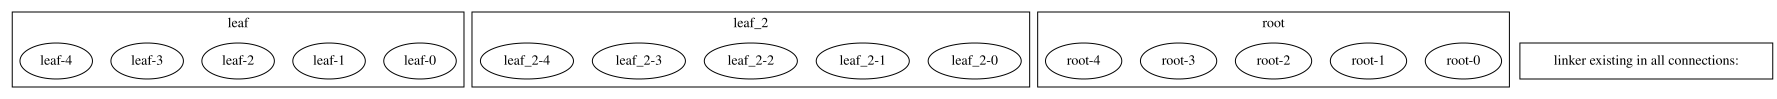

In [2]:
import layout as layout

con.create_graph()

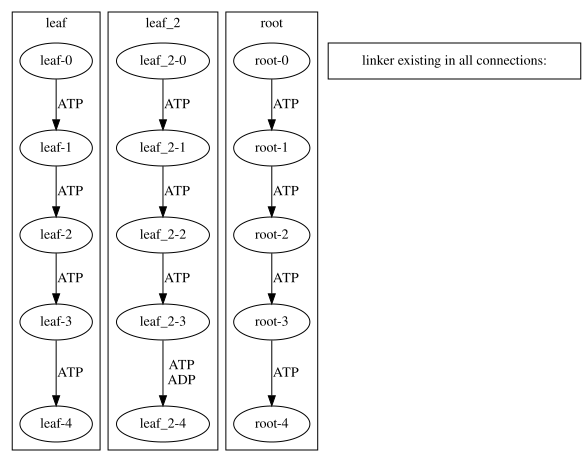

In [3]:
from model_duplication.constraints.linker import Linker

con.add_linker_series("ATP",last2first=False)
con.add_linker(
    Linker(
        "ADP",
        source="leaf_2-3",
        destination="leaf_2-4"
    )
)
con.create_graph()

In [ ]:
con.graph_with_bokeh()

In [ ]:
con.graph_with_plotly()

In [ ]:
from cobra import Model, Metabolite, Reaction
from igraph import Graph


def cobra2igraph(model:Model):
    g = Graph()

    metabolite:Metabolite
    for metabolite in model.metabolites:
        g.add_vertex(name= metabolite.id, color = "aliceblue")

    reaction: Reaction
    for reaction in model.reactions:
        g.add_vertex(name= reaction.id, color = "darkmagenta")
        for metabolite, coeff in reaction.metabolites.items():
            # direction
            if coeff > 0:
                g.add_edge(source= reaction.id, target= metabolite.id, coeff = coeff)
            else:
                g.add_edge(source= metabolite.id, target= reaction.id, coeff = coeff)

    return g


In [ ]:
import networkx as nx

def cobra2networkx(model: Model):
    graph = nx.DiGraph()

    for metabolite in model.metabolites:
        graph.add_node(metabolite.id, type = "metabolite")

    for reaction in model.reactions:
        graph.add_node(reaction.id, type = "reaction")
        for metabolite, coeff in reaction.metabolites.items():
            if coeff >0:
                graph.add_edge(reaction.id, metabolite.id, coeff = coeff, type = "reaction")
            else:
                graph.add_edge(metabolite.id, reaction.id, coeff = -coeff, type = "reaction")

    return graph

In [ ]:
from ipysigma import Sigma
from cobra.test import create_test_model

model =  create_test_model(model_name="textbook")
g = cobra2networkx(model)

# Displaying the graph
Sigma(g, node_color="type", edge_color="type", clickable_edges = True, edge_size="coeff", edge_size_range = (0.1, 3))


In [9]:
from cobra.test import create_test_model

model =  create_test_model(model_name="textbook")
graph = cobra2igraph(model)

In [10]:
g = graph

In [ ]:
from plotly.graph_objs import Scatter

layt=g.layout('lgl')
labels=list(g.vs['name'])
color =list(g.vs['color'])
E=[e.tuple for e in g.es]
N = len(labels)

Xn=[layt[k][0] for k in range(N)]
Yn=[layt[k][1] for k in range(N)]

Xe=[]
Ye=[]
for e in E:
    Xe+=[layt[e[0]][0],layt[e[1]][0], None]
    Ye+=[layt[e[0]][1],layt[e[1]][1], None]

trace1=Scatter(x=Xe,
               y=Ye,
               mode='lines',
               line= dict(color='rgb(210,210,210)', width=0.2),
               hoverinfo='none'
               )
trace2=Scatter(x=Xn,
               y=Yn,
               mode='markers',
               name='ntw',
               marker=dict(symbol='circle-dot',
                                        size=5,
                                        color=color,
                                        line=dict(color='rgb(50,50,50)', width=0.5)
                                        ),
               text=labels,
               hoverinfo="text",
               )


In [12]:
from plotly.graph_objs import *

axis=dict(showline=False, # hide axis line, grid, ticklabels and  title
          zeroline=False,
          showgrid=False,
          showticklabels=False,
          title=''
          )

width=800
height=800

layout=Layout(title= "Coauthorship network of scientists working on network theory and experiment"+\
              "<br> Data source: <a href='https://networkdata.ics.uci.edu/data.php?id=11'> [1]</a>",
    font= dict(size=12),
    showlegend=False,
    autosize=False,
    width=width,
    height=height,
    xaxis=layout.XAxis(axis),
    yaxis=layout.YAxis(axis),
    margin=layout.Margin(
        l=40,
        r=40,
        b=85,
        t=100,
    ),
    hovermode='closest',
    annotations=[
           dict(
           showarrow=False,
            text='This igraph.Graph has the Kamada-Kawai layout',
            xref='paper',
            yref='paper',
            x=0,
            y=-0.1,
            xanchor='left',
            yanchor='bottom',
            font=dict(
            size=14
            )
            )
        ]
    )

data=[trace1, trace2]
fig=Figure(data=data, layout=layout)
fig.show()


In [13]:
g = con._constraint2networkx()

In [14]:
Sigma(g, clickable_edges = True, edge_size="1")

Sigma(nx.DiGraph with 15 nodes and 12 edges)

In [15]:
con = Constraints()
con.add_sub_models(["root", "leaf", "leaf_2"], [1, 2, 1])
con.add_time_slots(5, 2)

In [16]:
con.add_linker_series("ATP",last2first=True)

In [17]:
g = con._constraint2networkx()
Sigma(g, clickable_edges = True, edge_size="2", node_size="2", edge_size_range=(2,2))

Sigma(nx.DiGraph with 15 nodes and 15 edges)

In [18]:
import ipycytoscape
import ipywidgets as widgets

cytoscapeobj = ipycytoscape.CytoscapeWidget()
g = nx.complete_graph(7)
cytoscapeobj.graph.add_graph_from_networkx(g)
cytoscapeobj.set_layout(name='grid', nodeSpacing=10, edgeLengthVal=10)
display(cytoscapeobj)

CytoscapeWidget(cytoscape_layout={'name': 'grid', 'nodeSpacing': 10, 'edgeLengthVal': 10}, cytoscape_style=[{'…

In [19]:
# Manipulate a graph using NetworkX

nx_graph = nx.complete_graph(7)

# Using its algorithms
nx.shortest_path(nx_graph, 1, 5)

[1, 5]

In [20]:
# Create a new NX graph without using a button

cytoscapeobj.graph.add_graph_from_networkx(nx_graph)

# Manipulate the NX graph using cytoscape

cytoscapeobj.set_layout(name='grid', nodeSpacing=10, edgeLengthVal=10)

cytoscapeobj.graph.add_graph_from_networkx(nx.complete_graph(5))

display(cytoscapeobj)

CytoscapeWidget(cytoscape_layout={'name': 'grid', 'nodeSpacing': 10, 'edgeLengthVal': 10}, cytoscape_style=[{'…

In [21]:
import ipycytoscape
import ipywidgets as widgets

cytoscapeobj = ipycytoscape.CytoscapeWidget()
g = nx.complete_graph(7)
cytoscapeobj.graph.add_graph_from_networkx(g)
cytoscapeobj.set_layout(name='grid', nodeSpacing=10, edgeLengthVal=10)
display(cytoscapeobj)

CytoscapeWidget(cytoscape_layout={'name': 'grid', 'nodeSpacing': 10, 'edgeLengthVal': 10}, cytoscape_style=[{'…

In [22]:
# Manipulate a graph using NetworkX

nx_graph = nx.complete_graph(7)

# Using its algorithms
nx.shortest_path(nx_graph, 1, 5)

[1, 5]

In [23]:
# Create a new NX graph without using a button

cytoscapeobj.graph.add_graph_from_networkx(nx_graph)

# Manipulate the NX graph using cytoscape

cytoscapeobj.set_layout(name='grid', nodeSpacing=10, edgeLengthVal=10)

cytoscapeobj.graph.add_graph_from_networkx(nx.complete_graph(5))

display(cytoscapeobj)

CytoscapeWidget(cytoscape_layout={'name': 'grid', 'nodeSpacing': 10, 'edgeLengthVal': 10}, cytoscape_style=[{'…